# Crosspower and Coherence Significance

In this script, we repeat the crosspower and coherence calculations, but now we assess whether any relationships identified are different from stochastic noise, and therefore whether they are statistically significant.

In [1]:
# Import needed libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from matplotlib.patches import FancyArrowPatch
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import FixedLocator
import xarray as xr
import pandas as pd
import seaborn as sns
import import_ipynb
import pickle as pkl

# importing wavelet functions and plotting utilities
from wavelets_wrapper_posh.quick_wavelet import run_full_wavelet_analysis, run_double_wavelet_analysis, unmirror_wavelet_power, unmirror_icwt, unmirror_crosspower, unmirror_coherence, unmirror_phase
from wavelets_wrapper_posh.plot_utils import plot_wavelet_power, plot_coherence, plot_phase

# import functions to estimate significance thresholds
from wavelets_wrapper_posh.significance_ar1 import estimate_significance_threshold_crosswavelet

# define fig directory
picture_dir = './figures'

# import the dataframe
data = pd.read_csv('./data/EVI_precip_table_site_12b.csv')
data['Date'] = pd.to_datetime(data['Date'])

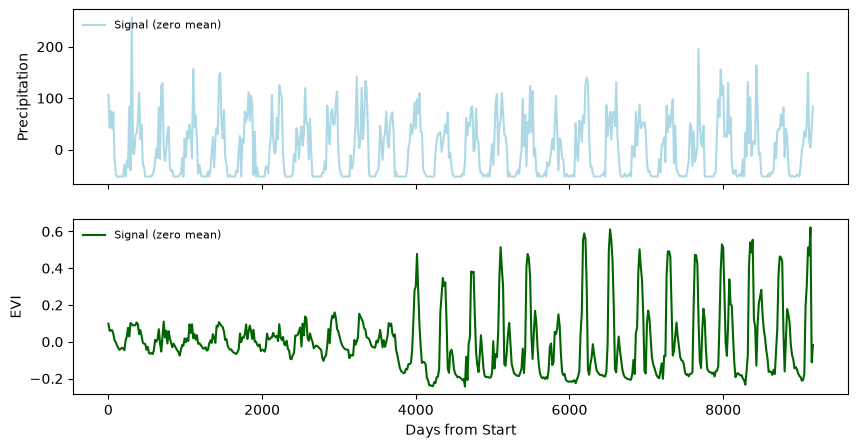

In [2]:
# extract the EVI and precipitation series as arrays
sig_evi = data['EVI'].values
sig_prec = data['Precipitation'].values
days_from_start = data['Days_from_Start'].values

# zero mean the data
sig_prec_zero_mean = sig_prec - np.mean(sig_prec)
sig_evi_zero_mean = sig_evi - np.mean(sig_evi)

# plot 
fig, ax = plt.subplots(figsize=(10,5), nrows=2, ncols=1, sharex=True)
for i, signal in enumerate([sig_prec_zero_mean, sig_evi_zero_mean]):
    color  = 'lightblue' if np.array_equal(signal, sig_prec_zero_mean) else 'darkgreen'
    ylabel = 'Precipitation' if np.array_equal(signal, sig_prec_zero_mean) else 'EVI'
    ax[i].plot(days_from_start, signal, label='Signal (zero mean)', color=color)
    if i == 0:
        ax[i].set_xlabel('')
    else:
        ax[i].set_xlabel('Days from Start')
    ax[i].set_ylabel(ylabel)
    ax[i].legend(loc='upper left', fontsize=8, frameon=False)

In [ ]:
# run coherence + crosspower
_, _, _, _, _, wp_env, _, _, _, _, _, wp_evi, xypower_df, phasexy_df, R2ns_df, _, _, _ = run_double_wavelet_analysis(
    sig_prec_zero_mean, sig_evi_zero_mean,
    dt=16, mirror=True, wf='morlet',
    dj=0.1, om0=6, normmean=True,
    mirrormethod=3, period_min=5, period_max=20,
)

# unmirror
period_max_val=len(sig_prec_zero_mean)*16-16 
print(f"Period max value: {period_max_val}")

wp_env, sumpow_env = unmirror_wavelet_power(
    sig_prec_zero_mean, wp_env,
    period_min=20, period_max=period_max_val,
)
wp_evi, sumpow_evi = unmirror_wavelet_power(
    sig_evi_zero_mean, wp_evi,
    period_min=20, period_max=period_max_val,
)
xypower, xysumpow = unmirror_crosspower(
    sig_prec_zero_mean, xypower_df,
    period_min=20, period_max=period_max_val,
)
phasexy = unmirror_phase(
    sig_prec_zero_mean, phasexy_df,
    period_min=20, period_max=period_max_val,
)
R2ns, R2ns_sumpow = unmirror_coherence(
    sig_evi_zero_mean, R2ns_df,
    period_min=20, period_max=period_max_val,
)
    
    
# Significance treshold for cross-wavelet power, this will take long because it runs 1000 simulations of the cross-wavelet power and coherence
significance_tresholds_dict = estimate_significance_threshold_crosswavelet(sig_prec_zero_mean, 
                                                                            sig_evi_zero_mean,
                                                                            n_ensemble=1000, n=None, dt=16, 
                                                                            max_period=None, alpha=None)

# save dictionary results
results_dict = {
    "prec_power": wp_env,
    "prec_power_sumpow": sumpow_env,
    "evi_power": wp_evi,
    "evi_power_sumpow": sumpow_evi,
    "crosswavelet": xypower,
    "crosswavelet_sumpow": xysumpow,
    "coherence": R2ns,
    "coherence_sumpow": R2ns_sumpow,
    "phase": phasexy,
    "crosswavelet_significance": significance_tresholds_dict["crosspower"],
    "coherence_significance": significance_tresholds_dict["coherence"],
    "crosspower_significance_sumpow": significance_tresholds_dict["crosspower_sumpow"],
    "coherence_significance_sumpow": significance_tresholds_dict["coherence_sumpow"]
    }

# Might take a long time to compute, so save results to pkl file so easier for plotting later on
with open(f"results_python.pkl", "wb") as f:
            pkl.dump(results_dict, f)


Calculating coherence with pycwt...

Period max value: 9168
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle rem

KeyboardInterrupt: 

In [4]:
# open pkl file to load results
with open(f"results_python.pkl", "rb") as f:
    results_dict = pkl.load(f)

## Plotting

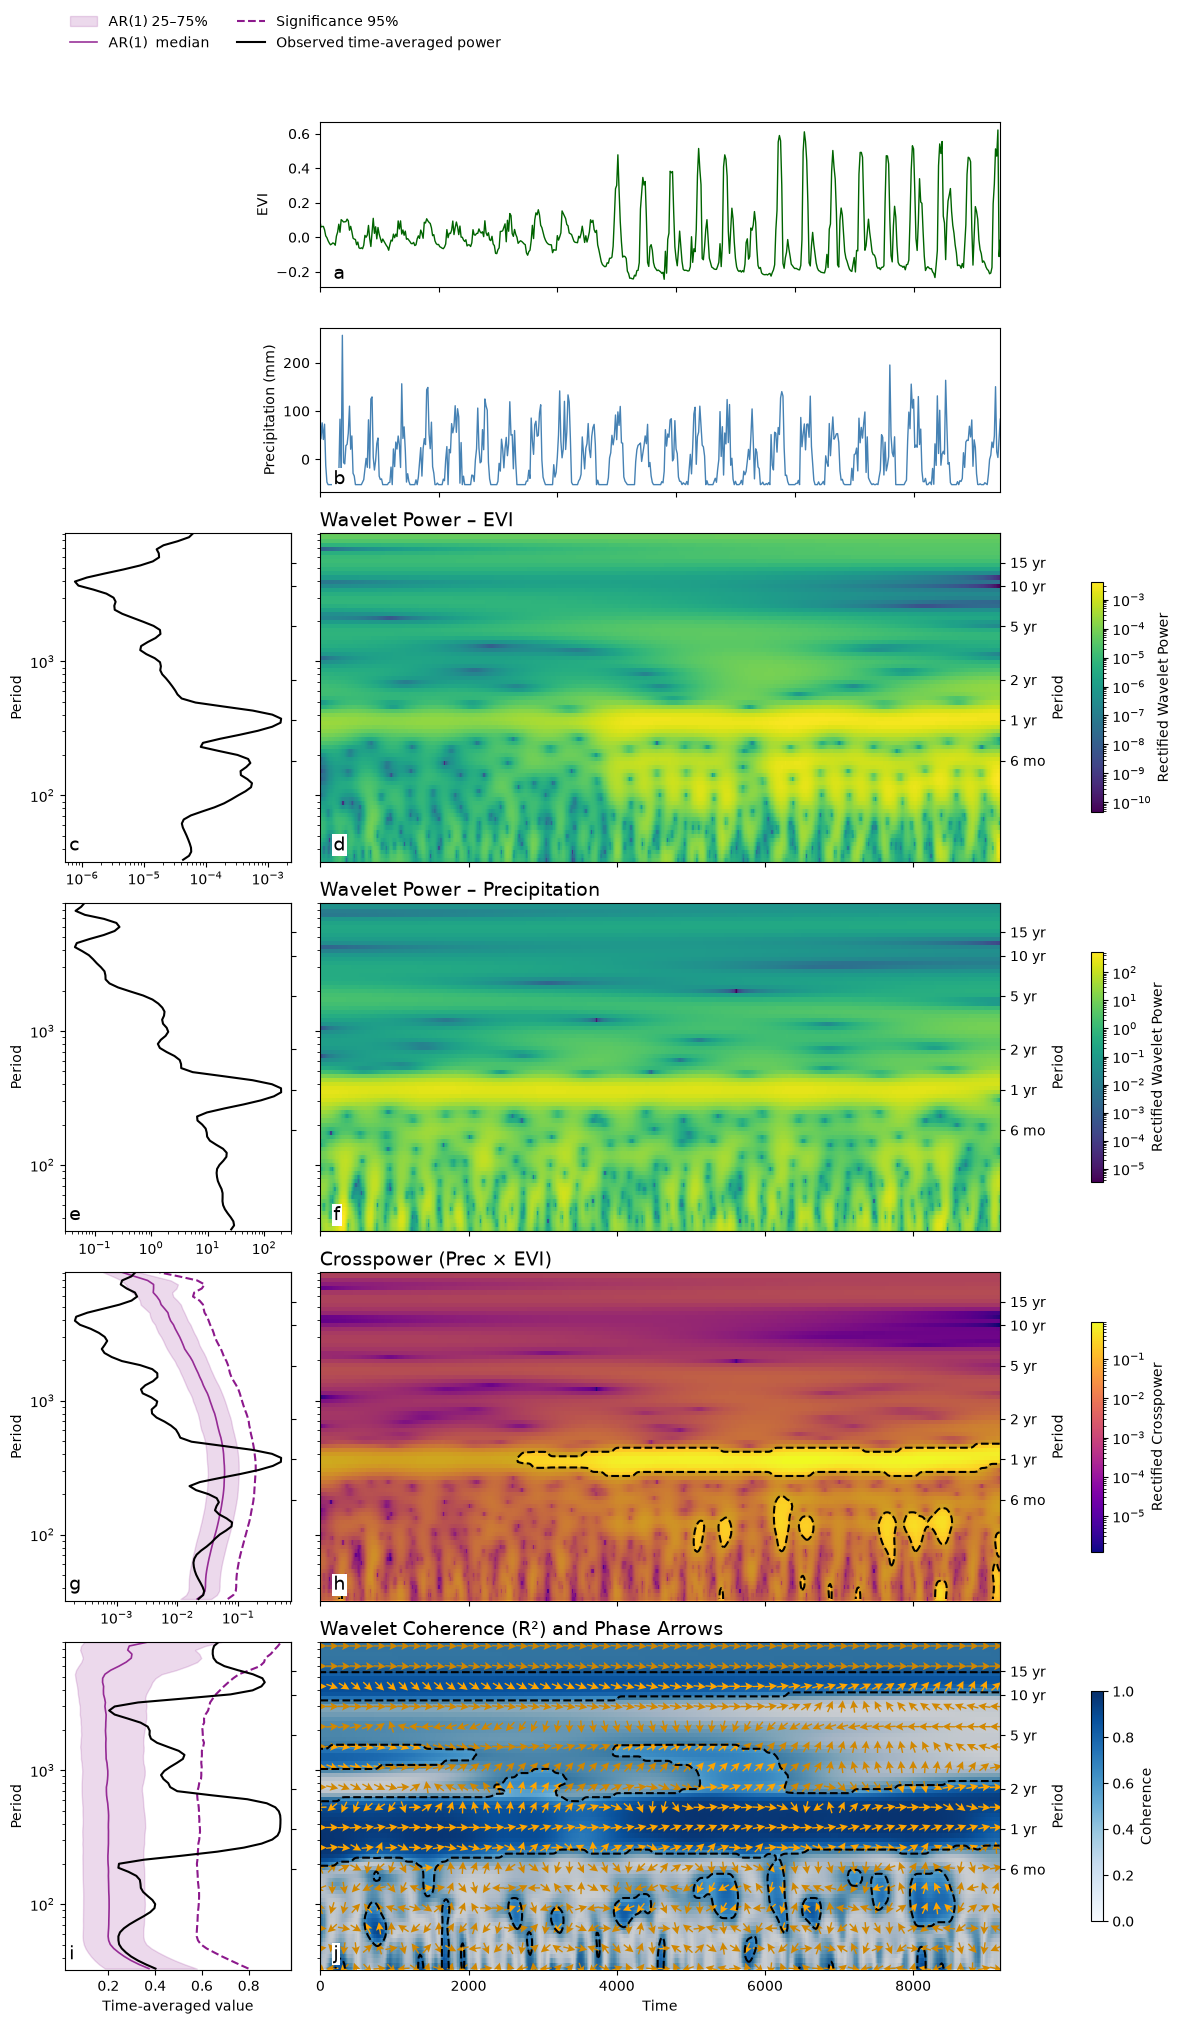

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# SETTINGS
# ─────────────────────────────────────────────────────────────────────────────
TICKS = [182, 365, 730, 1825, 3650, 5475]
TICK_LABELS = ["6 mo", "1 yr", "2 yr", "5 yr", "10 yr", "15 yr"]

PHASE_TIME_STEP = 10
PHASE_PERIOD_STEP = 5

YMIN = 32
LAST_ROW = 5

# ─────────────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def to_grid(df, value_col):
    """Long df (period, time, value) -> DataFrame index=period, columns=time."""
    return df.pivot(index="period", columns="time", values=value_col)

def sumpow_series(obj, col=None):
    """Accept a Series or a DataFrame and return a Series indexed by period."""
    if isinstance(obj, pd.DataFrame):
        if col is not None and col in obj.columns:
            return obj[col]
        return obj.iloc[:, 0]
    return obj

def p95_matrix(df):
    """Long df (time, period, p95) -> DataFrame index=time, columns=period."""
    if df is None:
        return None
    return df.pivot(index="time", columns="period", values="p95")

def significance_mask(p95_mat, grid, sigma=1.5):
    """Smoothed boolean mask (period x time) of where power exceeds the p95 null."""
    p95_al, rect_al = p95_mat.align(grid.T, join="inner")
    exceeds = (rect_al.values > p95_al.values).T
    return gaussian_filter(exceeds.astype(float), sigma=sigma)

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 24))
gs = GridSpec(6, 2, width_ratios=[1, 4],
              height_ratios=[1, 1, 2, 2, 2, 2], wspace=0.05, hspace=0.15)

panel_labels = iter("abcdefghij")

def add_panel_label(ax, label):
    ax.text(0.02, 0.02, label, transform=ax.transAxes, fontsize=14, 
            va="bottom", ha="left", zorder=20,
            bbox=dict(facecolor="white", edgecolor="none", pad=1))

# ─────────────────────────────────────────────────────────────────────────────
# ROWS 0–1: TIME SERIES
# ─────────────────────────────────────────────────────────────────────────────
ts_configs = [
    {"signal": sig_evi_zero_mean,  "color": "darkgreen", "y_label": "EVI"},
    {"signal": sig_prec_zero_mean, "color": "steelblue", "y_label": "Precipitation (mm)"},
]

for row, cfg in enumerate(ts_configs):
    ax = fig.add_subplot(gs[row, 1])
    ax.plot(cfg["signal"], color=cfg["color"], linewidth=1)
    ax.set_ylabel(cfg["y_label"])
    ax.margins(x=0)
    ax.tick_params(labelbottom=False)
    add_panel_label(ax, next(panel_labels))

    # invisible colorbar to keep widths aligned with the wavelet panels
    dummy = fig.colorbar(plt.cm.ScalarMappable(cmap="viridis"),
                         ax=ax, pad=0.1, shrink=0.7)
    dummy.ax.set_visible(False)

# ─────────────────────────────────────────────────────────────────────────────
# WAVELET ROW FUNCTION
# ─────────────────────────────────────────────────────────────────────────────
legend_handles, legend_labels = None, None

def build_wavelet_row(fig, gs, row, grid, sumpow, title, cmap, norm, clabel,
                      xscale="log", sig_stats=None, sig_p95=None, phase=None):
    global legend_handles, legend_labels
    """
    Left : time-averaged power (+ null median / 25–75% / 95% if sig_stats given)
    Right: wavelet field (+ 95% significance contour if sig_p95 given, + phase arrows)
    """
    period = grid.index.values
    time = grid.columns.values
    power = grid.values

    ax_avg = fig.add_subplot(gs[row, 0])
    ax_main = fig.add_subplot(gs[row, 1], sharey=ax_avg)
    add_panel_label(ax_avg, next(panel_labels))
    add_panel_label(ax_main, next(panel_labels))

    # ── LEFT PANEL ──────────────────────────────────────────────────────────
    if sig_stats is not None:
        ax_avg.fill_betweenx(period, sig_stats["p25"].values, sig_stats["p75"].values,
                             color="purple", alpha=0.15, label="AR(1) 25–75%")
        ax_avg.plot(sig_stats["median"].values, period, color="purple",
                    alpha=0.8, lw=1.2, label="AR(1)  median")
        ax_avg.plot(sig_stats["p95"].values, period, color="purple",
                    alpha=0.9, ls="--", lw=1.5, label="Significance 95%")

    ax_avg.plot(sumpow.values, period, color="black", lw=1.5,
                label="Observed time-averaged power")

    ax_avg.set_xscale(xscale)
    ax_avg.set_yscale("log")
    ax_avg.set_xlabel("Time-averaged value" if row == LAST_ROW else "")
    ax_avg.set_ylabel("Period")
    ax_avg.set_ylim(YMIN, period.max())

    # <-- add this, right after the observed-power plot
    if sig_stats is not None and legend_handles is None:
        legend_handles, legend_labels = ax_avg.get_legend_handles_labels()

    secax_avg = ax_avg.secondary_yaxis("right")
    secax_avg.yaxis.set_major_locator(FixedLocator(TICKS))
    secax_avg.minorticks_off()

    # ── RIGHT PANEL ─────────────────────────────────────────────────────────
    X, Y = np.meshgrid(time, period)
    pcm = ax_main.pcolormesh(time, period, power, shading="auto",
                             norm=norm, cmap=cmap)

    if sig_p95 is not None:
        smoothed = significance_mask(sig_p95, grid)
        # shade NON-significant area, outline significant area
        ax_main.contourf(X, Y, smoothed, levels=[0, 0.5], colors=["black"], alpha=0.18, zorder=10)
        ax_main.contour(X, Y, smoothed, levels=[0.5], colors="black",
                        linewidths=1.5, linestyles="--")

    # ── PHASE ARROWS ────────────────────────────────────────────────────────
    if phase is not None:
        ph = phase[phase["period"].between(period.min(), period.max())]
        ph_grid = ph.pivot(index="period", columns="time", values="phasexy")
        ph_grid = ph_grid.loc[ph_grid.index.intersection(grid.index),
                              ph_grid.columns.intersection(grid.columns)]
        ph_sub = ph_grid.iloc[::PHASE_PERIOD_STEP, ::PHASE_TIME_STEP]

        PX, PY = np.meshgrid(ph_sub.columns.values, ph_sub.index.values)

        ph_vals = ph_sub.values                 # subsampled, same shape as PX/PY
        U = np.cos(np.deg2rad(ph_vals))         # drop deg2rad if your phase is already in radians
        V = np.sin(np.deg2rad(ph_vals))

        ax_main.quiver(PX, PY, U, V, color="orange", pivot="mid", angles="uv", scale=55,
                    width=0.002, headwidth=6, headlength=6, headaxislength=5, zorder=1)

    # ── FORMATTING ──────────────────────────────────────────────────────────
    ax_main.set_yscale("log")
    ax_main.set_title(title, pad=5, fontsize=14, loc="left")
    if row != LAST_ROW:
        ax_main.set_xlabel("")
        ax_main.tick_params(labelbottom=False)
    else:
        ax_main.set_xlabel("Time")
    ax_main.set_ylim(YMIN, period.max())
    plt.setp(ax_main.get_yticklabels(), visible=False)

    fig.colorbar(pcm, ax=ax_main, pad=0.1, label=clabel, shrink=0.7)

    secax = ax_main.secondary_yaxis("right")
    secax.yaxis.set_major_locator(FixedLocator(TICKS))
    secax.set_yticklabels(TICK_LABELS)
    secax.set_ylabel("Period")
    secax.minorticks_off()

# ─────────────────────────────────────────────────────────────────────────────
# ROW CONFIGS (mapped to your results_dict keys)
# ─────────────────────────────────────────────────────────────────────────────
wavelet_row_configs = [
    # Row 2 — EVI power
    dict(row=2,
         grid=to_grid(results_dict["evi_power"], "rectified_power"),
         sumpow=sumpow_series(results_dict["evi_power_sumpow"], "rectified_power"),
         title="Wavelet Power – EVI",
         cmap="viridis", norm=LogNorm(), clabel="Rectified Wavelet Power",
         xscale="log",
         sig_stats=None, sig_p95=None),     # no significance saved for single signals

    # Row 3 — Precipitation power
    dict(row=3,
         grid=to_grid(results_dict["prec_power"], "rectified_power"),
         sumpow=sumpow_series(results_dict["prec_power_sumpow"], "rectified_power"),
         title="Wavelet Power – Precipitation",
         cmap="viridis", norm=LogNorm(), clabel="Rectified Wavelet Power",
         xscale="log",
         sig_stats=None, sig_p95=None),

    # Row 4 — Crosspower
    dict(row=4,
         grid=to_grid(results_dict["crosswavelet"], "xypower_rectified"),
         sumpow=sumpow_series(results_dict["crosswavelet_sumpow"], "xypower_rectified"),
         title="Crosspower (Prec × EVI)",
         cmap="plasma", norm=LogNorm(), clabel="Rectified Crosspower",
         xscale="log",
         sig_stats=results_dict["crosspower_significance_sumpow"],
         sig_p95=p95_matrix(results_dict["crosswavelet_significance"])),

    # Row 5 — Coherence + phase arrows
    dict(row=5,
         grid=to_grid(results_dict["coherence"], "R2ns"),
         sumpow=sumpow_series(results_dict["coherence_sumpow"], "R2ns"),
         title="Wavelet Coherence (R²) and Phase Arrows",
         cmap="Blues", norm=Normalize(vmin=0, vmax=1), clabel="Coherence",
         xscale="linear",
         sig_stats=results_dict["coherence_significance_sumpow"],
         sig_p95=p95_matrix(results_dict["coherence_significance"]),
         phase=results_dict["phase"]),
]

for cfg in wavelet_row_configs:
    build_wavelet_row(fig, gs, **cfg)

fig.legend(legend_handles, legend_labels,
           loc="upper left", bbox_to_anchor=(0.12, 0.93),
           ncol=2, frameon=False, fontsize=10)

# ─────────────────────────────────────────────────────────────────────────────
# SAVE + SHOW
# ─────────────────────────────────────────────────────────────────────────────
fig.savefig(f"{picture_dir}/wavelet_full_summary.png",
            dpi=600, bbox_inches="tight")
plt.show()

Regarding phase:

- Right (→)	In phase (0°): the signals peak and trough together
- Left (←)	Anti-phase (180°): one peaks when the other troughs
- Up (↑)	One signal leads the other by a quarter cycle (90°)
- Down (↓)	The opposite quarter-cycle lead (-90°)